In [10]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision.transforms.functional as TF

from torch.utils.data import Dataset,DataLoader
from torchvision import transforms

In [11]:
class DoubleConv(nn.Module):
    def __init__(self,in_channels,out_channels):
        super(DoubleConv,self).__init__()
        self.conv=nn.Sequential(
            nn.Conv2d(in_channels,out_channels,3,1,1,bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

        nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True)
        )

    def forward(self,x):
        return self.conv(x)

In [12]:
class UNet(nn.Module):
    def __init__(self,in_channels=3,out_channels=3):
        super().__init__()
        features=[64,128,256,512]

        self.downs=nn.ModuleList()
        self.ups=nn.ModuleList()

        self.pool=nn.MaxPool2d(2)

        #encoder
        c=in_channels
        for feature in features:
            self.downs.append(DoubleConv(c,feature))
            c=feature

        #Bottleneck
        self.bottleneck=DoubleConv(features[-1],features[-1]*2)

        #Decoder
        for feature in reversed(features):
            self.ups.append(nn.ConvTranspose2d(feature*2,feature,2,2))
            self.ups.append(DoubleConv(feature*2,feature))

        self.final=nn.Conv2d(features[0],out_channels,kernel_size=1)

    def forward(self,x):
        skips=[]

        #Encoder
        for down in self.downs:
            x=down(x)
            skips.append(x)
            x=self.pool(x)

        #Bottleneck
        x=self.bottleneck(x)
        skips.reverse()

        #Decoder
        for i in range(0,len(self.ups),2):
            x=self.ups[i](x)

            skip=skips[i//2]

            if x.shape!=skip.shape:
                x=TF.resize(x,size=skip.shape[2:])

            x=torch.cat((skip,x),dim=1)
            x=self.ups[i+1](x)

        x=self.final(x)
        return torch.sigmoid(x)

In [13]:
model=UNet()

In [14]:
x=torch.rand(4,3,256,256)
y=model(x)
print(y.shape)

torch.Size([4, 3, 256, 256])


In [23]:
class OxfordPetDataset(Dataset):

    def __init__(self,root,split="trainval",transform=None):

        self.root=root
        self.transform=transform

        self.image_dir=os.path.join(root,"images")
        self.mask_dir=os.path.join(root,"annotations","trimaps")

        split_file=os.path.join(root,"annotations",f"{split}.txt")

        self.files=[]

        with open(split_file,"r") as f:

            for line in f.readlines():

                self.files.append(line.split()[0])

    def __len__(self):

        return len(self.files)

    def __getitem__(self,index):

        name=self.files[index]

        image=Image.open(
            os.path.join(self.image_dir,name+".jpg")
        ).convert("RGB")

        mask=Image.open(
            os.path.join(self.mask_dir,name+".png")
        )

        if self.transform:

            image=self.transform(image)

            mask=TF.resize(mask,(256,256))

            mask=torch.from_numpy(np.array(mask)).long()

            mask=mask-1

        return image,mask

In [24]:
transform=transforms.Compose([

    transforms.Resize((256,256)),
    transforms.ToTensor()

])

In [25]:
train_dataset=OxfordPetDataset(
    root="dataset",
    transform=transform,
)
test_dataset=OxfordPetDataset(
    root='dataset',
    split='test',
    transform=transform
)

In [26]:
train_loader=DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)
test_loader=DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False
)

In [27]:
images,masks=next(iter(loader))

print(images.shape)

print(masks.shape)

torch.Size([4, 3, 256, 256])
torch.Size([4, 256, 256])


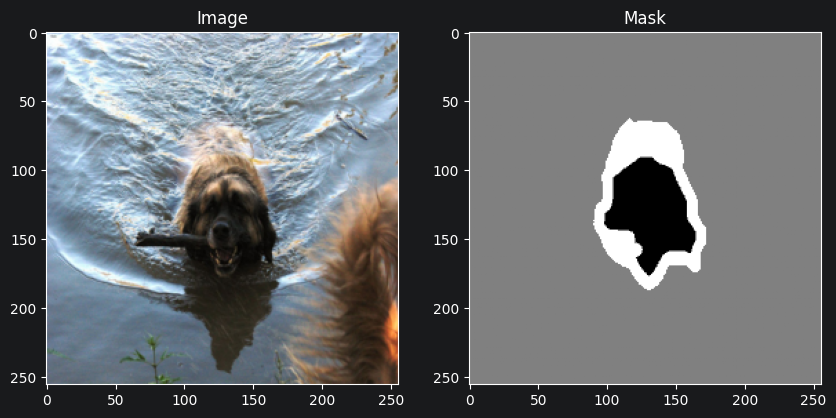

In [28]:
plt.figure(figsize=(10,5))

plt.subplot(121)
plt.imshow(images[0].permute(1,2,0))
plt.title("Image")

plt.subplot(122)
plt.imshow(masks[0],cmap="gray")
plt.title("Mask")

plt.show()

In [39]:
learning_rate=0.0001
epochs=10

criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=learning_rate)

device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [37]:
model=UNet()
model.to(device)

UNet(
  (downs): ModuleList(
    (0): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (1): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_run

In [38]:
images,masks=next(iter(train_loader))

images=images.to(device)

masks=masks.to(device)

optimizer.zero_grad()

outputs=model(images)

loss=criterion(outputs,masks)

loss.backward()

optimizer.step()

print(loss.item())

1.1096810102462769


In [ ]:
for epoch in range(epochs):
    model.train()
    total_loss=0
    for images,masks in test_loader:
        images,masks=images.to(device),masks.to(device)

        optimizer.zero_grad()
        output=model(images)
        loss=criterion(output,masks)
        loss.backward()
        optimizer.step()

        total_loss+=loss.item()

    avg_loss = total_loss/len(train_loader)
    print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')

In [ ]:
torch.save({
            "epoch": epochs,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
        }, "checkpoint.pth")

In [ ]:
model.eval()

with torch.no_grad():

    image, mask = test_dataset[0]

    output = model(image.unsqueeze(0).to(device))

    pred = torch.argmax(output, dim=1).squeeze(0).cpu()

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(131)
plt.imshow(image.permute(1,2,0))
plt.title("Input Image")
plt.axis("off")

plt.subplot(132)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(133)
plt.imshow(pred, cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.show()